# Validate GSI Landslide Inventory
This notebook visualizes the cleaned GSI landslide inventory dataset.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Create docs dir if not exists
os.makedirs('../docs/data', exist_ok=True)

## Load Data

In [2]:
df = pd.read_csv('../data/processed/landslides/gsi_landslide_inventory_clean.csv')
print(f"Total Rows: {len(df)}")
df.head()

Total Rows: 35723


,sl_no,slide_no,state,district,slide_name,nh_sh_location,latitude,longitude,material_involved,movement_type,history,pdf_page
0,1,ASM/HKN/83D07/2020/2,Assam,Hailakandi,Kukinala slide,Kukinala,24.27,92.50,Debris,Slide,NaN,1
1,2,AS/HKN/83D11/2020/1,Assam,Hailakandi,Jalnachaura slide,Jalnachaura,24.31,92.56,Debris,Slide,NaN,1
2,3,AS/HKN/83D10/2020/6,Assam,Hailakandi,Nandagram slide,Nandagram Pt. I,24.32,92.51,Debris,Slide,NaN,1
3,4,AS/HKN/83D11/2020/4,Assam,Hailakandi,Nishkar slide,Mahapur,24.43,92.55,Debris,Slide,NaN,1
4,5,AS/KRJ/83D07/2020/1,Assam,Karimganj,Paglacherra slide,PaglacherraPunj,24.44,92.50,Rock,Slide,NaN,1


## 4. Latitude/Longitude Validation Summary

In [3]:
valid_coords = df.dropna(subset=['latitude', 'longitude'])
print(f"Valid Coordinates: {len(valid_coords)}")
print(f"Latitude Range: {valid_coords['latitude'].min()} to {valid_coords['latitude'].max()}")
print(f"Longitude Range: {valid_coords['longitude'].min()} to {valid_coords['longitude'].max()}")

Valid Coordinates: 35723
Latitude Range: -23.736217 to 34.758333
Longitude Range: 72.8095 to 96.61719


## 1. Scatter Map of All Landslide Coordinates

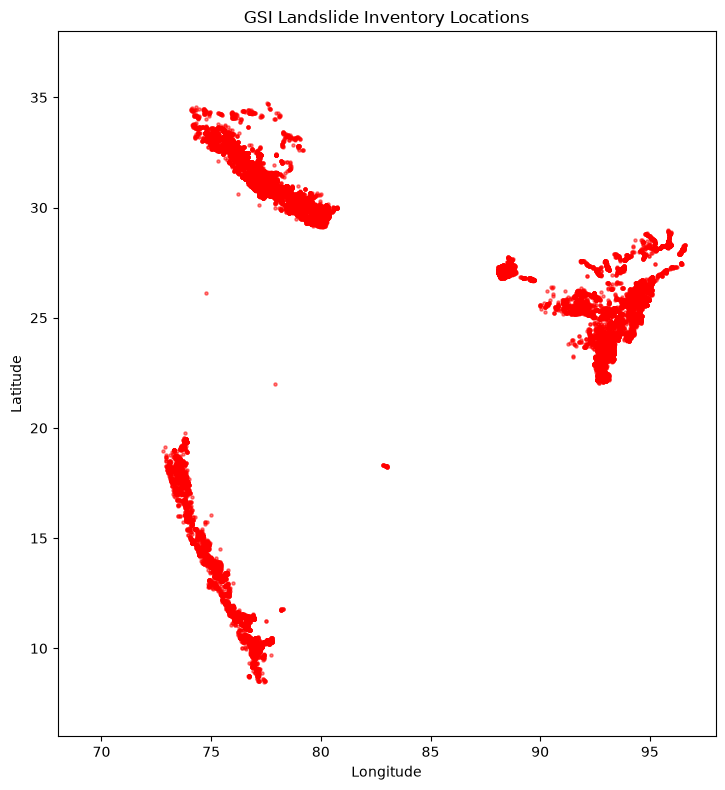

In [4]:
gdf = gpd.GeoDataFrame(
    valid_coords, 
    geometry=gpd.points_from_xy(valid_coords.longitude, valid_coords.latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(ax=ax, markersize=5, color='red', alpha=0.5)
plt.title('GSI Landslide Inventory Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Focus on India's approximate bounding box
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.tight_layout()

# Save the map as requested
plt.savefig('../docs/data/gsi_inventory_map.png', dpi=300)
plt.show()

## 2. State-wise Count Chart

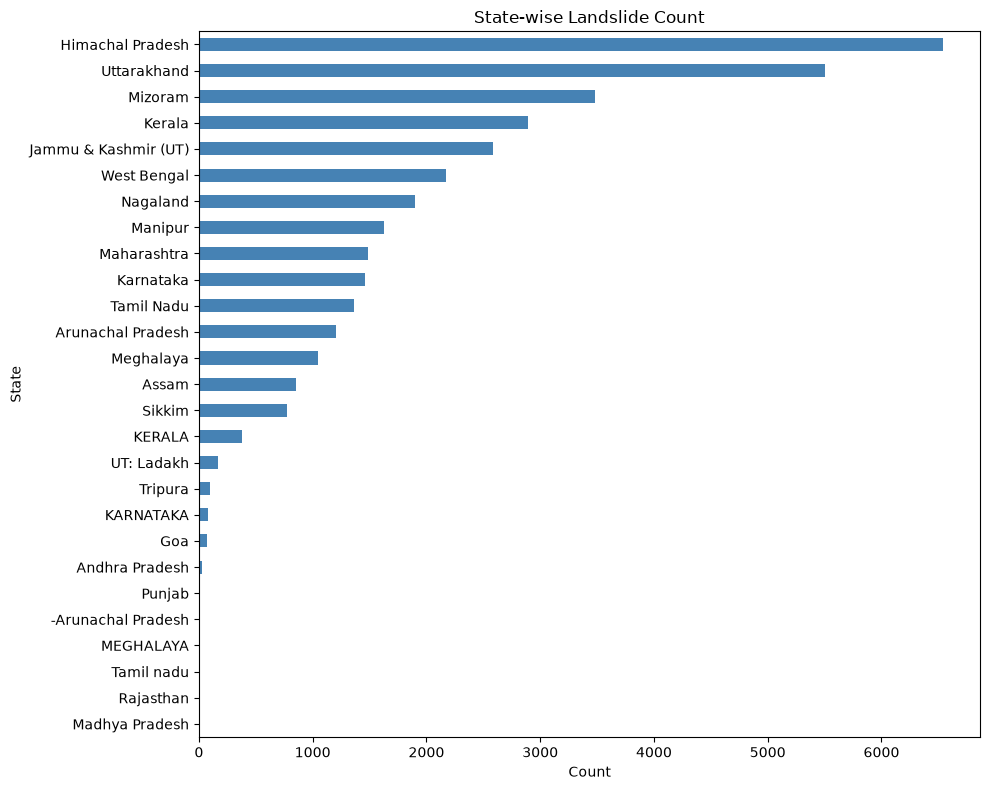

In [5]:
state_counts = df['state'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
state_counts.plot(kind='barh', ax=ax, color='steelblue')
plt.title('State-wise Landslide Count')
plt.xlabel('Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 3. District-wise Top 20 Count Chart

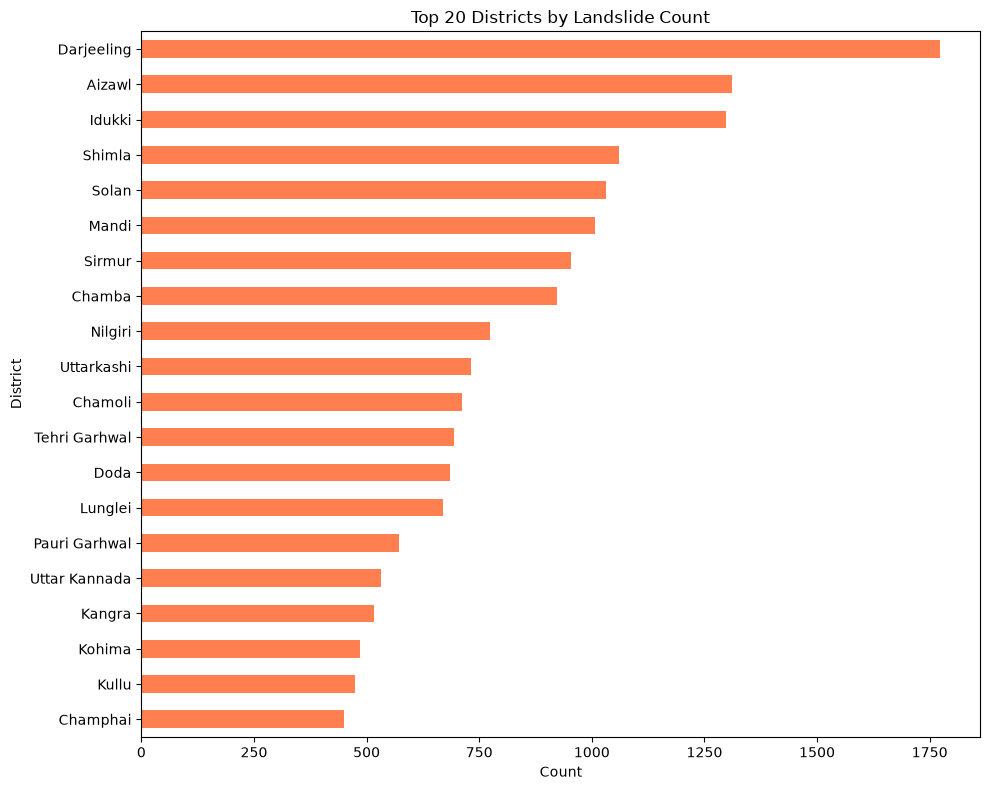

In [6]:
district_counts = df['district'].value_counts().head(20).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
district_counts.plot(kind='barh', ax=ax, color='coral')
plt.title('Top 20 Districts by Landslide Count')
plt.xlabel('Count')
plt.ylabel('District')
plt.tight_layout()
plt.show()